# Aplicación de DTW

Objetivos:

- Comparar sujetos
    * DTW multivariado entre sujetos. 42x42
    * Clustering sobre la matriz DTW.
    * UMAP u otro método para visualizar grupos.
- Comparar señales
    * DTW LH ↔ RHR dentro de cada sujeto para estudiar desfases hormonales.
- Opcional hacer enfasamiento de ciclos
- Valores medios de todos

In [1]:
# ── Instalación de dependencias ──────────────────────────────────────────────
# !pip install -q dtaidistance umap-learn scikit-learn pandas numpy matplotlib seaborn scipy

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from dtaidistance import dtw, dtw_ndim
import umap
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Paleta consistente
PHASE_COLORS = {
    'Menstrual':   "#F53C4B",
    'Follicular':  "#2F5CE5",
    'Fertility':   "#39E057",
    'Luteal':      "#E6EF35",
}
sns.set_theme(style='whitegrid', font_scale=1.1)
print('✓ Imports OK')

/Users/daragama/Documents/ProyectosVarios/DTW_mcphases/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports OK


## 1. Carga y limpieza de datos

In [3]:
from pathlib import Path
from dotenv import load_dotenv
import os


load_dotenv()

DATA_PATH = Path(os.getenv("DATA_PATH"))
OUTPUT_PATH = Path(os.getenv("OUTPUT_PATH"))

print(DATA_PATH)
print(f"Data path: {DATA_PATH}")
print(f"Output path: {OUTPUT_PATH}")

/Users/daragama/DBS/mcphases1.0.0
Data path: /Users/daragama/DBS/mcphases1.0.0
Output path: /Users/daragama/Documents/ProyectosVarios/DTW_mcphases/output


In [4]:
# ── Carga ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_PATH / "mcphases_consolidated_2022.csv")

# Columnas de señales fisiológicas disponibles
SIGNAL_COLS = ['movement_pct', 'rhr_value', 'hr_pc1', 'hr_pc2', 'hr_pc3',
               'lh', 'estrogen', 'wtmp_pc1', 'wtmp_pc2', 'wtmp_pc3']

print(f'Shape: {df.shape}')
print(f'Sujetos: {df["id"].nunique()}')
print(f'Días por sujeto (mediana): {df.groupby("id")["day_in_study"].count().median()}')
print(df.head())
print(df[["wtmp_pc1"]].isna().sum())

Shape: (3698, 13)
Sujetos: 42
Días por sujeto (mediana): 90.0
   id  day_in_study  movement_pct  rhr_value    hr_pc1    hr_pc2    hr_pc3  \
0   1             1      0.078335  74.785346 -0.087502 -1.584184  0.756453   
1   1             2      0.079656  80.407307  4.716075  0.174529  0.696757   
2   1             3      0.174725  84.686869  5.546794  0.622128  1.111908   
3   1             4      0.086781  83.852219  0.130233 -1.319226  1.926947   
4   1             5      0.006944   0.000000  8.362226 -0.195472  0.846024   

    lh  estrogen       phase  wtmp_pc1  wtmp_pc2  wtmp_pc3  
0  2.9      94.2  Follicular       NaN       NaN       NaN  
1  1.2     226.3  Follicular       NaN       NaN       NaN  
2  3.5     276.8  Follicular -4.029523  2.463657 -0.533221  
3  1.8     322.1   Fertility -4.000154  2.382851 -1.749736  
4  4.6     244.9   Fertility       NaN       NaN       NaN  
wtmp_pc1    508
dtype: int64


### 1.1 Interpolación por sujeto

In [5]:
import numpy as np
import pandas as pd

# ============================================================================
# VARIABLES CONTINUAS A INTERPOLAR
# ============================================================================

SIGNAL_COLS = [
    'movement_pct',
    'rhr_value',
    'hr_pc1',
    'hr_pc2',
    'hr_pc3',
    'lh',
    'estrogen',
    'wtmp_pc1',
    'wtmp_pc2',
    'wtmp_pc3'
]

# ============================================================================
# LIMPIEZA BÁSICA
# ============================================================================

# Reemplazar artefactos conocidos
df = df.copy()
df['rhr_value'] = df['rhr_value'].replace(0, np.nan)

# Guardar cantidad de nulos antes de interpolar
na_before = df[SIGNAL_COLS].isna().sum()

# ============================================================================
# INTERPOLACIÓN POR SUJETO
# ============================================================================

def interpolate_subject(g):
    g = g.sort_values('day_in_study').copy()

    g[SIGNAL_COLS] = (
        g[SIGNAL_COLS]
        .interpolate(method='linear', limit_direction='both')
    )

    return g

df_clean = (
    df
    .sort_values(['id', 'day_in_study'])
    .groupby('id')
    .apply(interpolate_subject)
    .reset_index()
)

# ============================================================================
# RESUMEN DE IMPUTACIÓN
# ============================================================================

na_after = df_clean[SIGNAL_COLS].isna().sum()

summary = pd.DataFrame({
    'missing_before': na_before,
    'missing_after': na_after,
    'filled': na_before - na_after
})

print("\nResumen de interpolación:")
print(summary)

print("\nShape final:")
print(df_clean.shape)

print("\nNulos restantes:")
print(df_clean[SIGNAL_COLS].isna().sum())

print("\nColumnas:")
print(df_clean.columns.tolist())
df_clean.to_csv(OUTPUT_PATH / "df_clean.csv", index=False)

# ============================================================================
# VERIFICACIONES
# ============================================================================

assert 'id' in df_clean.columns, "La columna 'id' no existe."
assert 'day_in_study' in df_clean.columns, "La columna 'day_in_study' no existe."

print("\nSujetos:", df_clean['id'].nunique())
print("Observaciones:", len(df_clean))


Resumen de interpolación:
              missing_before  missing_after  filled
movement_pct               0              0       0
rhr_value                782              0     782
hr_pc1                   215             90     125
hr_pc2                   215             90     125
hr_pc3                   215             90     125
lh                       223              0     223
estrogen                 224              0     224
wtmp_pc1                 508              0     508
wtmp_pc2                 508              0     508
wtmp_pc3                 508              0     508

Shape final:
(3698, 14)

Nulos restantes:
movement_pct     0
rhr_value        0
hr_pc1          90
hr_pc2          90
hr_pc3          90
lh               0
estrogen         0
wtmp_pc1         0
wtmp_pc2         0
wtmp_pc3         0
dtype: int64

Columnas:
['id', 'level_1', 'day_in_study', 'movement_pct', 'rhr_value', 'hr_pc1', 'hr_pc2', 'hr_pc3', 'lh', 'estrogen', 'phase', 'wtmp_pc1', 'wtmp_pc2', 

In [6]:
# sujetos con nulos restantes
subjects_with_nans = df_clean[df_clean[SIGNAL_COLS].isna().any(axis=1)]['id'].unique()
print("\nSujetos con nulos restantes:", subjects_with_nans)
# eliminar sujeto (solo es 1 )
df_clean = df_clean[~df_clean['id'].isin(subjects_with_nans)]
print("\nSujetos después de eliminar con nulos:", df_clean['id'].nunique())
# revisar nulos restantes
print("\nNulos restantes:")
print(df_clean[SIGNAL_COLS].isna().sum())


Sujetos con nulos restantes: [30]

Sujetos después de eliminar con nulos: 41

Nulos restantes:
movement_pct    0
rhr_value       0
hr_pc1          0
hr_pc2          0
hr_pc3          0
lh              0
estrogen        0
wtmp_pc1        0
wtmp_pc2        0
wtmp_pc3        0
dtype: int64


Tenemos un tensor:

41×60×7

donde:

eje 1 = sujeto
eje 2 = tiempo normalizado
eje 3 = variable

## 2. Valores medios por fase del ciclo

In [7]:
phase_means = (
    df_clean.dropna(subset=['phase'])
            .groupby(['id', 'phase'])[SIGNAL_COLS]
            .mean()
            .reset_index()
)

# Tabla resumen global (media ± std por fase)
summary = (
    phase_means.groupby('phase')[SIGNAL_COLS]
               .agg(['mean', 'std'])
)
summary

movement_pct            rhr_value              hr_pc1            \
                   mean       std       mean       std      mean       std   
phase                                                                        
Fertility      0.195207  0.078779  67.934248  7.255303  0.092845  1.186036   
Follicular     0.199999  0.069790  66.903966  7.050209  0.048433  1.238533   
Luteal         0.196908  0.070807  69.476900  7.610023  0.012942  1.084570   
Menstrual      0.194723  0.068736  67.960072  7.646394  0.103302  1.612086   

              hr_pc2              hr_pc3                  lh            \
                mean       std      mean       std      mean       std   
phase                                                                    
Fertility  -0.139492  0.699628  0.073298  0.729600  9.913735  4.119028   
Follicular -0.209367  0.729427 -0.075140  0.735562  4.513069  2.280487   
Luteal     -0.013846  0.619839  0.171659  0.742413  3.643390  1.573883   
Menstrual  -0.165595  0.644638 -0.025644  0.739342  3.912647  1.650395   

              estrogen             wtmp_pc1            wtmp_pc2            \
                  mean        std      mean       std      mean       std   
phase                                                                       
Fertility   190.649339  84.726961  0.159407  1.603469 -0.111220  1.040341   
Follicular  111.013429  57.860322  0.082513  1.574415 -0.296365  1.231828   
Luteal      154.182475  81.420272  0.108082  1.532325  0.295913  1.069718   
Menstrual    99.192498  45.546945  0.078736  1.627444 -0.114222  1.168732   

            wtmp_pc3            
                mean       std  
phase                           
Fertility  -0.105153  0.764017  
Follicular -0.159798  0.916465  
Luteal      0.209041  0.597008  
Menstrual  -0.027331  0.612886

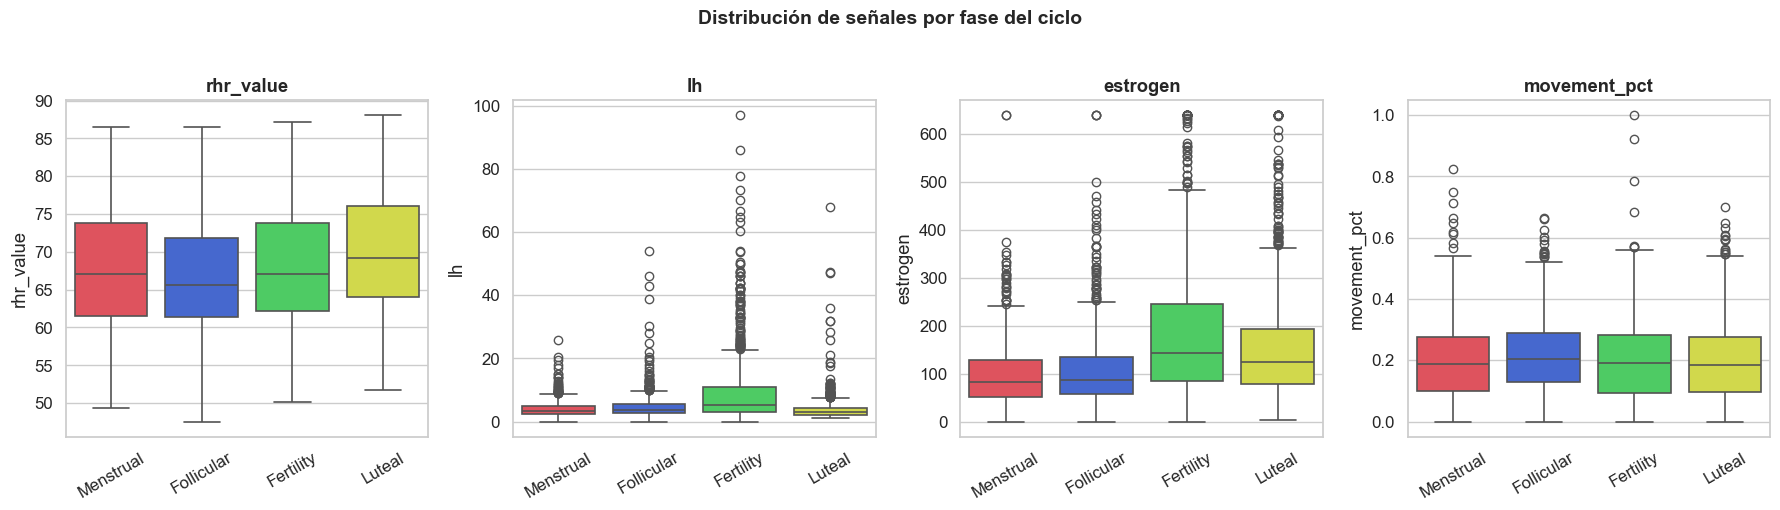

In [8]:
# ── Boxplots: señales clave por fase ─────────────────────────────────────────
signals_to_plot = ['rhr_value', 'lh', 'estrogen', 'movement_pct']
phase_order = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']

fig, axes = plt.subplots(1, len(signals_to_plot), figsize=(18, 5))
for ax, sig in zip(axes, signals_to_plot):
    data_plot = df_clean.dropna(subset=['phase', sig])
    present_phases = [p for p in phase_order if p in data_plot['phase'].unique()]
    palette = {p: PHASE_COLORS.get(p, 'gray') for p in present_phases}
    sns.boxplot(data=data_plot, x='phase', y=sig, order=present_phases,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(sig, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de señales por fase del ciclo', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'boxplot_por_fase.png', dpi=150, bbox_inches='tight')
plt.show()

> aqui se hizo el borrador pruebas, y está desordenado, la versión final (hecha basado en esto con ayuda de IA está en DTW_intrasujeto.py)

In [9]:
df_clean.groupby("id")["day_in_study"].nunique().min()
df_clean.groupby("id")["day_in_study"].nunique().max()

90

tenemos sujetos con 30 días y otros con 90. Veamos la distribución de días desiponibles de cada quién

In [10]:
lengths = (
    df_clean.groupby("id")["day_in_study"]
    .nunique()
    .sort_values()
)

print(lengths)

id
49    38
29    60
27    90
32    90
33    90
34    90
37    90
38    90
39    90
1     90
41    90
42    90
43    90
44    90
45    90
46    90
47    90
48    90
26    90
40    90
24    90
22    90
2     90
3     90
4     90
6     90
7     90
8     90
9     90
10    90
11    90
12    90
13    90
14    90
15    90
16    90
18    90
19    90
20    90
23    90
50    90
Name: day_in_study, dtype: int64


se quitan estos sujetos también

In [11]:
ids_with_few_data = df_clean.groupby("id")["day_in_study"].nunique()[df_clean.groupby("id")["day_in_study"].nunique() < 90]
print("\nSujetos con menos de 30 días de datos:", ids_with_few_data)


Sujetos con menos de 30 días de datos: id
29    60
49    38
Name: day_in_study, dtype: int64


## DF clean para estudio

In [12]:
# delete subjects with few data
df_clean = df_clean[~df_clean['id'].isin(ids_with_few_data.index)]
print("\nSujetos después de eliminar con pocos datos:", df_clean['id'].nunique())
print("\nShape final de df_clean:", df_clean.shape)
df_clean.to_csv(OUTPUT_PATH / "df_clean_final.csv", index=False)


Sujetos después de eliminar con pocos datos: 39

Shape final de df_clean: (3510, 14)


## 3. DTW entre sujetos (matriz 41×41) + Clustering + UMAP

### creacion de series

In [13]:
# ── Preparar series temporales multivariadas por sujeto ──────────────────────
MV_SIGNALS = df_clean[SIGNAL_COLS].columns.tolist()


from sklearn.preprocessing import StandardScaler

df_scaled = df_clean.copy()

# for sig in MV_SIGNALS:
#     scaler = StandardScaler()
#     df_scaled[sig] = scaler.fit_transform(df_scaled[[sig]])

subjects = sorted(df_scaled['id'].unique())
print(f'Sujetos: {len(subjects)}')

def get_subject_series(subject_id, signals=MV_SIGNALS):
    sub = (
        df_scaled[df_scaled['id'] == subject_id]
        .sort_values('day_in_study')
    )

    arr = []

    for sig in signals:
        vals = sub[sig].values.astype(float)

        mu = vals.mean()
        sd = vals.std()

        vals = (vals - mu) / (sd + 1e-8)

        arr.append(vals)

    return np.column_stack(arr)

series_dict = {sid: get_subject_series(sid) for sid in subjects}
print(f'Ejemplo matriz del sujeto shape: {series_dict[subjects[0]].shape}')

Sujetos: 39
Ejemplo matriz del sujeto shape: (90, 10)


60 filas (tiempo normalizado)

7 columnas (variables)

### DTW multivariado

In [14]:
# ── Calcular matriz DTW multivariada ─────────────────────────────────────────
# dtw_ndim.distance calcula DTW sobre series multidimensionales
n = len(subjects)
dtw_matrix = np.zeros((n, n))

print(f'Calculando DTW {n}×{n}...')
for i in range(n):
    for j in range(i + 1, n):
        s1 = series_dict[subjects[i]].astype(np.double)
        s2 = series_dict[subjects[j]].astype(np.double)
        d = dtw_ndim.distance(s1, s2)
        dtw_matrix[i, j] = d
        dtw_matrix[j, i] = d
    if i % 5 == 0:
        print(f'  Sujeto {i+1}/{n}')

print('✓ Matriz DTW calculada')
print(f'  Min: {dtw_matrix[dtw_matrix > 0].min():.2f}  Max: {dtw_matrix.max():.2f}')

Calculando DTW 39×39...
  Sujeto 1/39
  Sujeto 6/39
  Sujeto 11/39
  Sujeto 16/39
  Sujeto 21/39
  Sujeto 26/39
  Sujeto 31/39
  Sujeto 36/39
✓ Matriz DTW calculada
  Min: 33.65  Max: 42.46


In [15]:
upper = dtw_matrix[np.triu_indices_from(dtw_matrix, k=1)]

pd.Series(upper).describe()

count    741.000000
mean      37.595058
std        1.375649
min       33.652996
25%       36.679590
50%       37.566995
75%       38.487555
max       42.461333
dtype: float64

| Opción | Preprocesamiento                    | Mean DTW | SD DTW |     Rango |
| ------ | ----------------------------------- | -------: | -----: | --------: |
| A      | Estandarización por sujeto          |     37.6 |   1.38 | 33.7–42.5 |
| B      | Datos crudos                        |    876.1 |  370.5 |  249–2997 |
| C      | Estandarización global por variable |     38.8 |   9.62 | 23.2–74.9 |


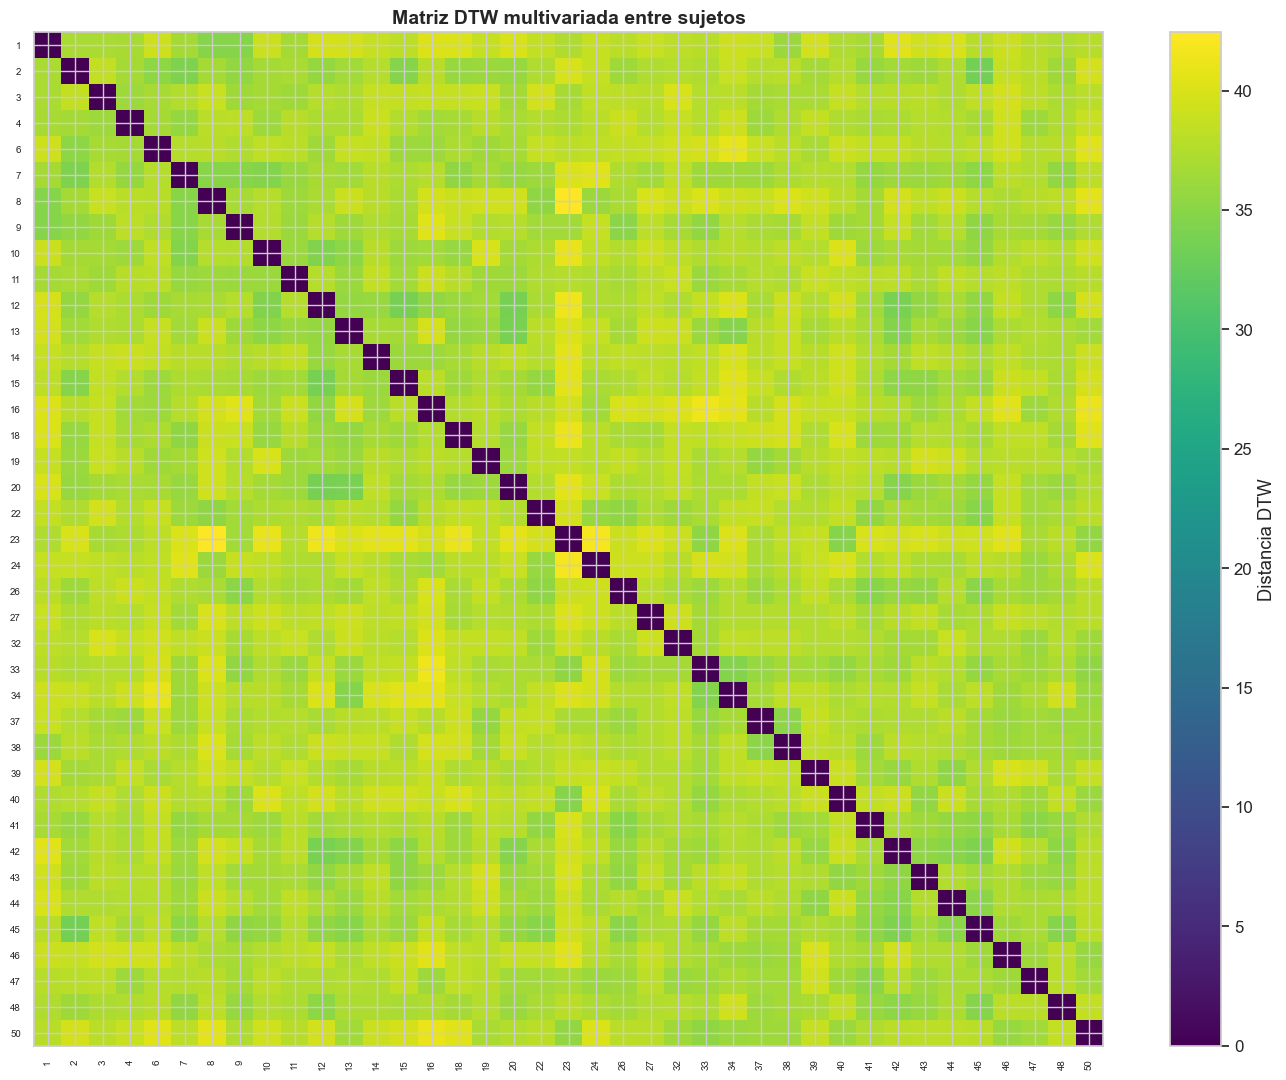

In [16]:
# ── Heatmap de la matriz DTW ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(dtw_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='Distancia DTW')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([str(s) for s in subjects], rotation=90, fontsize=7)
ax.set_yticklabels([str(s) for s in subjects], fontsize=7)
ax.set_title('Matriz DTW multivariada entre sujetos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'dtw_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##### versión con valores estandarizados
no se ven patrones aparentes, parece que DTW no encontró algún grupo, solo se ve la diagonal vs. todo lo demás
El rango total es:

42.46−33.65=8.81

y la desviación estándar es apenas:

1.38

#### versión cruda (*raw*)

Aquí, DTW está capturando tanto forma como magnitud.

se ven algunos sujetos [1, 39, 46] que tienen distancias muy grandes a la mayoría de los sujetos, pero no necesariamente se ven grupos definidos. El estrógeno puede estar dominando las distancias

LH            ~ 0-50
Estrogen      ~ 0-500
RHR           ~ 50-80
Movement      ~ 0-1
HR_PC1        ~ -3 a 3
WTMP_PC1      ~ -3 a 3

#### versión con estandarización por señal
daba cluster de 1 contra el resto

### Clustering

In [17]:
# ── Clustering jerárquico sobre DTW ──────────────────────────────────────────
# Convertir matriz de distancias a forma condensada
from scipy.spatial.distance import squareform

dtw_condensed = squareform(dtw_matrix)
Z = linkage(dtw_condensed, method='average')

# Selección de k óptimo por silhouette
sil_scores = {}
for k in range(2, min(10, n)):
    labels = fcluster(Z, k, criterion='maxclust')
    sil_scores[k] = silhouette_score(dtw_matrix, labels, metric='precomputed')

k_opt = max(sil_scores, key=sil_scores.get)
print(f'Scores silhouette: {sil_scores}')
print(f'k óptimo: {k_opt}  (silhouette={sil_scores[k_opt]:.3f})')

cluster_labels = fcluster(Z, k_opt, criterion='maxclust')

Scores silhouette: {2: 0.02567000212960587, 3: 0.019049766985209254, 4: 0.01780787602957153, 5: 0.017074911391334463, 6: 0.017293285618981726, 7: 0.018363902720835375, 8: 0.018275764337652246, 9: 0.01785791672683871}
k óptimo: 2  (silhouette=0.026)


La función squareform elimina:

la diagonal
la mitad repetida

y genera un vector condensado.
luego ´linkage´ ¿Qué dos clusters son ahora los más parecidos? hasta formar un cluster completo 
> la IA usó metodo  Ward que intenta minimizar el aumento de variabilidad interna. (clusters compactos), pero está hecho para distancias euclideanas. Para DTW se usa average o complete.


Agregar al reporte parte matemática de silhoutte score
| Score     | Interpretación        |
| --------- | --------------------- |
| > 0.70    | separación muy fuerte |
| 0.50–0.70 | buena estructura      |
| 0.25–0.50 | estructura moderada   |
| < 0.25    | estructura débil      |



In [18]:
import pandas as pd

pd.Series(cluster_labels).value_counts().sort_index()

# print id de cluster 2 
cluster_2_subjects = [subjects[i] for i in range(len(subjects)) if cluster_labels[i] == 1]
print(f'Sujetos en cluster 2: {cluster_2_subjects}')

Sujetos en cluster 2: [1, 9, 23, 26, 32, 33, 34, 37, 38, 40, 41, 46, 47, 50]


se hizo una verificación más detallada en dfToSeries.py. Conclusión

"Las señales seleccionadas muestran heterogeneidad interindividual, pero dicha variabilidad no se organiza en grupos discretos de comportamiento. En cambio, los participantes parecen distribuirse a lo largo de un continuo de perfiles fisiológicos, con la posible excepción de uno o pocos individuos atípicos."

### Dendrograma

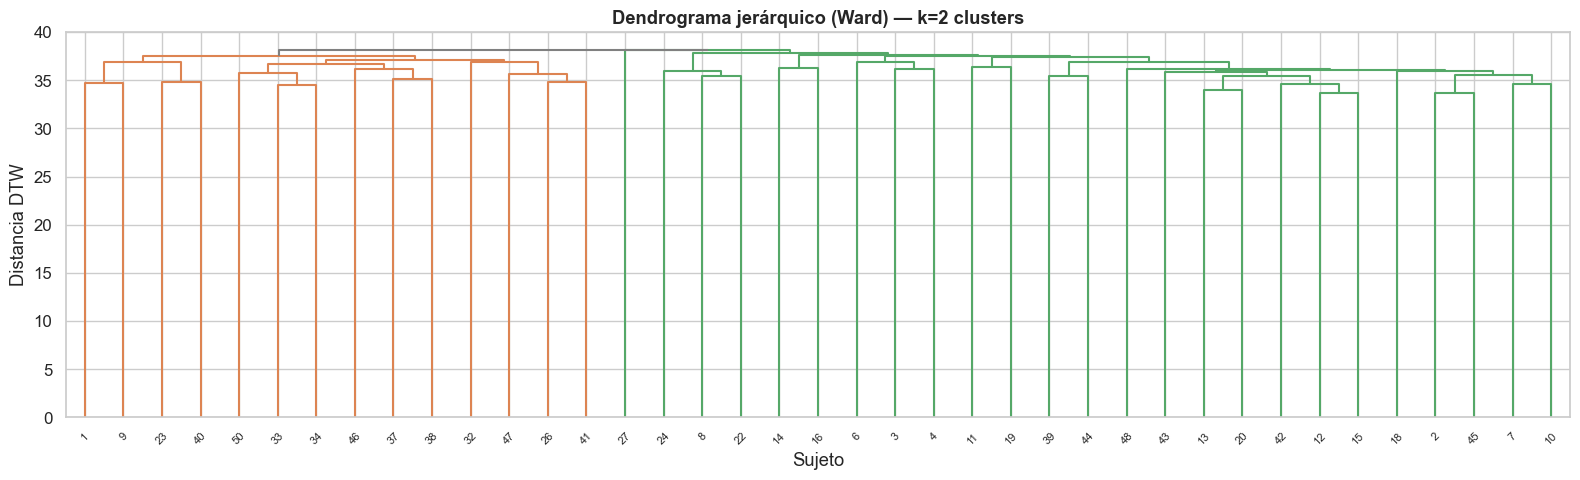

In [19]:
fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, labels=[str(s) for s in subjects],
           color_threshold=Z[-(k_opt-1), 2],
           above_threshold_color='gray', ax=ax)
ax.set_title(f'Dendrograma jerárquico (Ward) — k={k_opt} clusters', fontweight='bold')
ax.set_xlabel('Sujeto')
ax.set_ylabel('Distancia DTW')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

### t-SNE

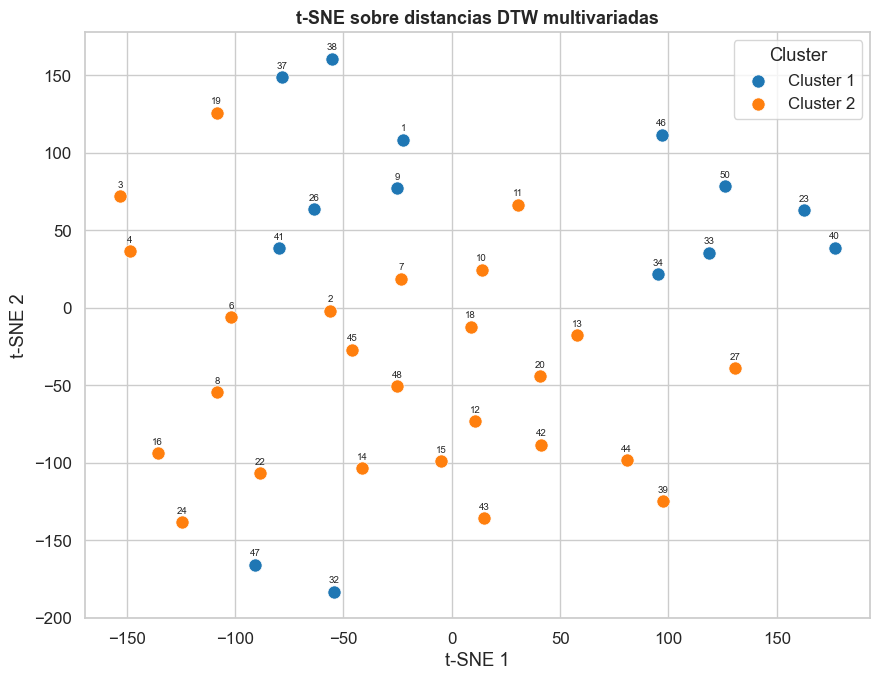

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── t-SNE sobre matriz de distancias DTW ─────────────────────────────────────

tsne = TSNE(
    n_components=2,
    metric='precomputed',
    perplexity=10,
    init='random',
    learning_rate='auto',
    random_state=42
)

embedding = tsne.fit_transform(dtw_matrix)

# ── Plot ─────────────────────────────────────────────────────────────────────

palette = sns.color_palette('tab10', k_opt)

fig, ax = plt.subplots(figsize=(9, 7))

for k in range(1, k_opt + 1):
    mask = cluster_labels == k

    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=[palette[k - 1]],
        label=f'Cluster {k}',
        s=90,
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )

    for idx in np.where(mask)[0]:
        ax.annotate(
            str(subjects[idx]),
            (embedding[idx, 0], embedding[idx, 1]),
            fontsize=7,
            ha='center',
            va='bottom',
            xytext=(0, 5),
            textcoords='offset points'
        )

ax.set_title(
    't-SNE sobre distancias DTW multivariadas',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

ax.legend(title='Cluster')

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / 'tsne_clusters.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### UMAP

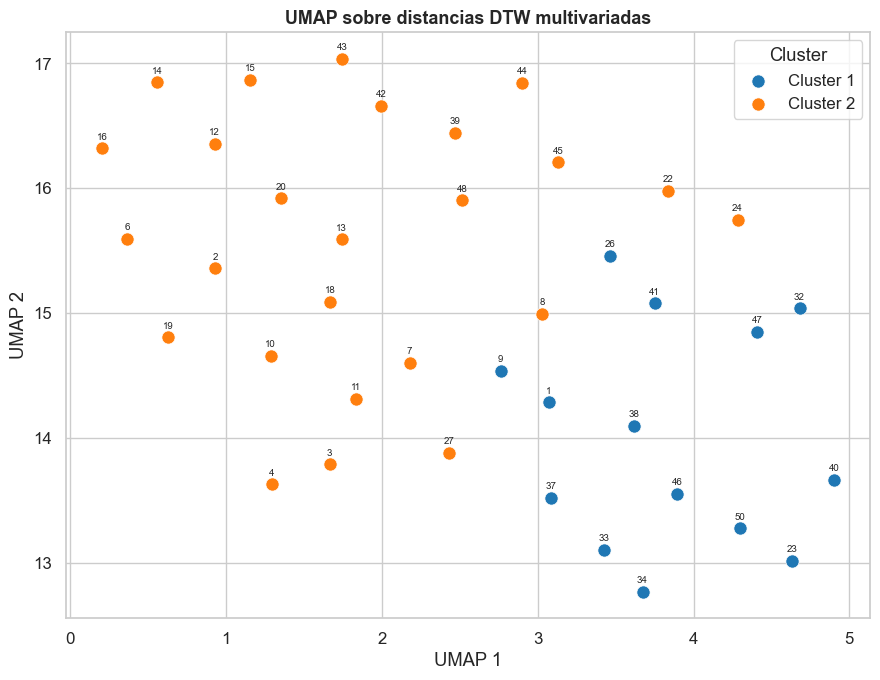

In [21]:
reducer = umap.UMAP(
    metric='precomputed',
    n_components=2,
    n_neighbors=min(10, n - 1),
    min_dist=0.3,
    random_state=42
)
embedding = reducer.fit_transform(dtw_matrix)

# Plot
palette = sns.color_palette('tab10', k_opt)
fig, ax = plt.subplots(figsize=(9, 7))
for k in range(1, k_opt + 1):
    mask = cluster_labels == k
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=[palette[k - 1]], label=f'Cluster {k}',
               s=90, edgecolors='white', linewidths=0.5, zorder=3)
    for idx in np.where(mask)[0]:
        ax.annotate(str(subjects[idx]),
                    (embedding[idx, 0], embedding[idx, 1]),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

ax.set_title('UMAP sobre distancias DTW multivariadas', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Tabla sujeto → cluster ────────────────────────────────────────────────────
subject_clusters = pd.DataFrame({'id': subjects, 'cluster': cluster_labels})
print(subject_clusters.groupby('cluster')['id'].apply(list).to_string())
subject_clusters.to_csv('subject_clusters.csv', index=False)
subject_clusters.head(10)

cluster
1    [1, 9, 23, 26, 32, 33, 34, 37, 38, 40, 41, 46,...
2    [2, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16,...


,id,cluster
0,1,1
1,2,2
2,3,2
3,4,2
4,6,2
5,7,2
6,8,2
7,9,1
8,10,2
9,11,2


## 4. DTW entre señales por sujeto (desfases hormonales)
Ahora hipóteisis: Dentro de un mismo sujeto, ¿qué tan sincronizadas están dos señales?

In [23]:
from dtaidistance import dtw
import numpy as np

def dtw_lag(subject_id, sig_a='lh', sig_b='rhr_value'):

    sub = (
        df_clean[df_clean['id'] == subject_id]
        .sort_values('day_in_study')
    )

    a = sub[sig_a].values.astype(float)
    b = sub[sig_b].values.astype(float)

    # eliminar NaN mediante interpolación
    def fill_nan(x):
        idx = np.arange(len(x))
        mask = ~np.isnan(x)

        if mask.sum() < 2:
            return None

        return np.interp(idx, idx[mask], x[mask])

    a = fill_nan(a)
    b = fill_nan(b)

    if a is None or b is None:
        return np.nan

    # estandarizar
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)

    a = a.astype(np.double)
    b = b.astype(np.double)

    # DTW
    _, paths = dtw.warping_paths(a, b)
    best_path = dtw.best_path(paths)

    # diferencias temporales
    lags = np.array([
        j - i
        for i, j in best_path
    ])

    return np.median(lags)

In [24]:
signal_pairs = [
    ('lh', 'rhr_value'),
    ('lh', 'estrogen'),
    ('estrogen', 'rhr_value'),
    ('lh', 'hr_pc1'),
    ('estrogen', 'wtmp_pc1'),
]

lag_results = []

for sid in subjects:

    row = {'id': sid}

    for sa, sb in signal_pairs:

        row[f'{sa}_to_{sb}_lag'] = dtw_lag(
            sid,
            sa,
            sb
        )

    lag_results.append(row)

lag_df = pd.DataFrame(lag_results)

lag_df.head()

,id,lh_to_rhr_value_lag,lh_to_estrogen_lag,estrogen_to_rhr_value_lag,lh_to_hr_pc1_lag,estrogen_to_wtmp_pc1_lag
0,1,-24.5,-12.0,-23.0,16.0,18.0
1,2,-3.5,-8.0,7.0,2.0,1.0
2,3,-23.0,-3.0,-15.0,2.0,2.0
3,4,8.0,-1.0,-13.0,5.0,-10.0
4,6,-10.0,9.0,-15.0,-34.0,4.0


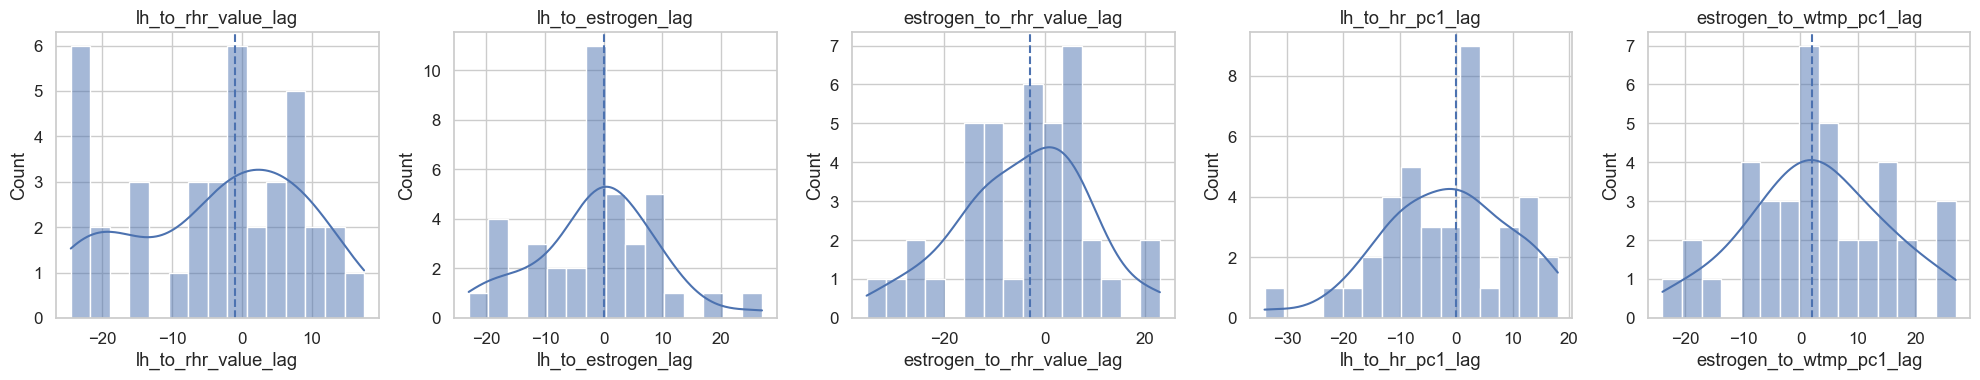

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

lag_cols = [c for c in lag_df.columns if '_lag' in c]

fig, axes = plt.subplots(
    1,
    len(lag_cols),
    figsize=(4 * len(lag_cols), 4)
)

for ax, col in zip(axes, lag_cols):

    sns.histplot(
        lag_df[col],
        bins=15,
        kde=True,
        ax=ax
    )

    ax.axvline(
        lag_df[col].median(),
        ls='--'
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [26]:
lag_df.describe()

,id,lh_to_rhr_value_lag,lh_to_estrogen_lag,estrogen_to_rhr_value_lag,lh_to_hr_pc1_lag,estrogen_to_wtmp_pc1_lag
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,24.846154,-3.525641,-1.179487,-4.282051,-1.782051,2.807692
std,15.441807,12.277466,10.408427,13.143837,11.355960,12.361664
min,1.000000,-24.500000,-23.000000,-35.500000,-34.000000,-24.000000
25%,11.500000,-15.250000,-6.500000,-12.500000,-8.500000,-5.000000
50%,23.000000,-1.000000,0.000000,-3.000000,0.000000,2.000000
75%,39.500000,6.500000,5.000000,4.500000,4.000000,11.500000
max,50.000000,17.500000,27.000000,23.000000,18.000000,27.000000


| Par de señales       | Mediana |
| -------------------- | ------: |
| LH → RHR             |      -1 |
| LH → Estrógeno       |       0 |
| Estrógeno → RHR      |      -3 |
| LH → HR_PC1          |       0 |
| Estrógeno → WTMP_PC1 |       2 |


Lo que estos números sugieren es:

DTW sí encuentra alineamientos entre señales.
Pero el lag medio derivado de la trayectoria DTW no es estable entre sujetos.
No parece existir una única relación temporal dominante.

¿Existe un desfase consistente entre LH y RHR a través de los sujetos y cuál es su magnitud típica?

**No se observa un desfase consistente entre señales cuando se resume la trayectoria DTW completa. Las medianas son cercanas a cero y la variabilidad entre sujetos es alta (≈10–13 días), lo que sugiere una heterogeneidad considerable en las relaciones temporales entre las señales fisiológicas y hormonales.**

friendly: Para cada sujeto y para cada par de señales, se obtuvo la trayectoria óptima de alineamiento mediante DTW. Posteriormente, se calculó un desfase temporal resumido como la mediana de las diferencias entre los índices alineados (j−i) a lo largo de dicha trayectoria. Esto produjo una estimación de desfase por sujeto para cada par de señales analizado, generando un total de 39 estimaciones por par de señales. Las distribuciones de estos desfases mostraron medianas cercanas a cero y una elevada variabilidad entre sujetos, lo que indica ausencia de un patrón temporal consistente a nivel de cohorte.

Se aplicó Dynamic Time Warping (DTW) para evaluar la sincronización temporal entre pares de señales fisiológicas y hormonales dentro de cada sujeto. A partir de la trayectoria óptima de alineamiento obtenida mediante DTW, se estimó un desfase temporal resumido como la diferencia entre los índices alineados de ambas señales.

Los resultados mostraron medianas de desfase cercanas a cero para todos los pares analizados (LH–RHR, LH–estrógeno, estrógeno–RHR, LH–HR_PC1 y estrógeno–WTMP_PC1). Sin embargo, la variabilidad entre sujetos fue elevada, con desviaciones estándar entre aproximadamente 10 y 13 días y rangos que abarcaron tanto valores positivos como negativos.

Estos hallazgos sugieren que no existe un patrón temporal uniforme de adelantamiento o retraso entre las señales estudiadas. Aunque DTW identificó alineamientos entre las series temporales, los desfases derivados de las trayectorias óptimas fueron altamente heterogéneos entre participantes, lo que impidió identificar una relación temporal consistente a nivel de cohorte.


## 5. Enfasamiento de ciclos por pico de LH

In [27]:
df_clean.head()

,id,level_1,day_in_study,movement_pct,rhr_value,hr_pc1,hr_pc2,hr_pc3,lh,estrogen,phase,wtmp_pc1,wtmp_pc2,wtmp_pc3
0,1,0,1,0.078335,74.785346,-0.087502,-1.584184,0.756453,2.9,94.2,Follicular,-4.029523,2.463657,-0.533221
1,1,1,2,0.079656,80.407307,4.716075,0.174529,0.696757,1.2,226.3,Follicular,-4.029523,2.463657,-0.533221
2,1,2,3,0.174725,84.686869,5.546794,0.622128,1.111908,3.5,276.8,Follicular,-4.029523,2.463657,-0.533221
3,1,3,4,0.086781,83.852219,0.130233,-1.319226,1.926947,1.8,322.1,Fertility,-4.000154,2.382851,-1.749736
4,1,4,5,0.006944,82.964636,8.362226,-0.195472,0.846024,4.6,244.9,Fertility,-3.118187,1.442505,-0.573877


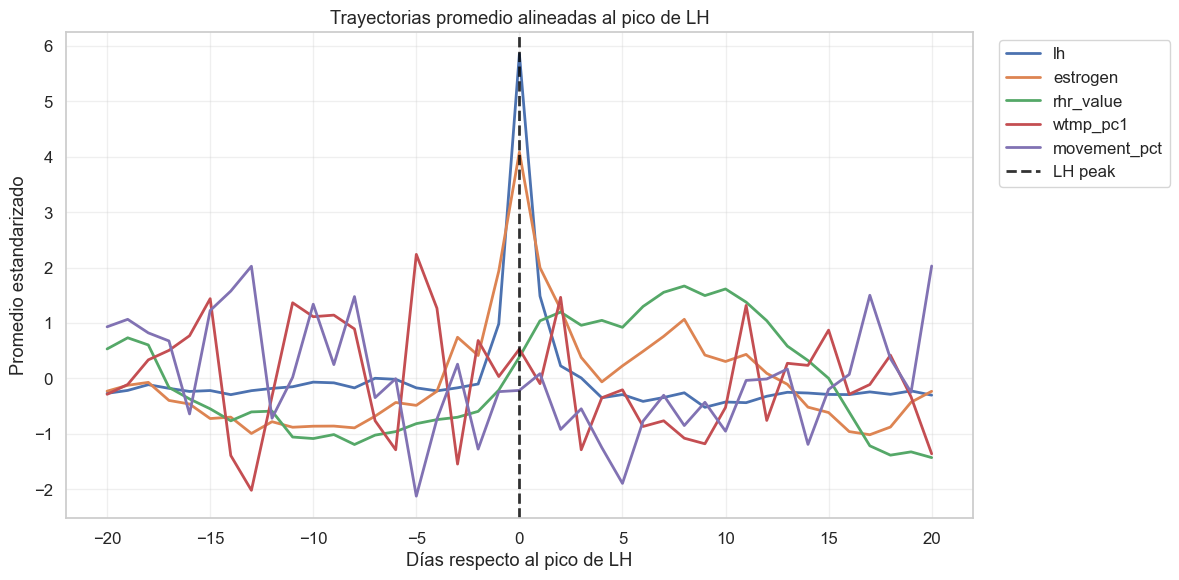

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Señales a visualizar
# ============================================================
signals = [
    "lh",
    "estrogen",
    "rhr_value",
    "wtmp_pc1",
    "movement_pct"
]

# ============================================================
# Alinear todos los sujetos al pico de LH
# ============================================================
aligned_subjects = []

for sid in subjects:

    sub = (
        df_clean[df_clean["id"] == sid]
        .sort_values("day_in_study")
        .copy()
    )

    peak_day = sub.loc[
        sub["lh"].idxmax(),
        "day_in_study"
    ]

    sub["day_from_lh_peak"] = (
        sub["day_in_study"] - peak_day
    )

    aligned_subjects.append(sub)

aligned_df = pd.concat(
    aligned_subjects,
    ignore_index=True
)

# ============================================================
# Limitar ventana alrededor del pico
# ============================================================
WINDOW = 20

aligned_df = aligned_df[
    aligned_df["day_from_lh_peak"].between(
        -WINDOW,
        WINDOW
    )
]

# ============================================================
# Promedio por día relativo al pico LH
# ============================================================
mean_curves = (
    aligned_df
    .groupby("day_from_lh_peak")[signals]
    .mean()
    .reset_index()
)

# ============================================================
# Estandarizar cada curva promedio
# (solo para visualización)
# ============================================================
plot_df = mean_curves.copy()

for sig in signals:

    mu = plot_df[sig].mean()
    sd = plot_df[sig].std()

    plot_df[sig] = (
        plot_df[sig] - mu
    ) / (sd + 1e-8)

# ============================================================
# Gráfica
# ============================================================
plt.figure(figsize=(12, 6))

for sig in signals:

    plt.plot(
        plot_df["day_from_lh_peak"],
        plot_df[sig],
        linewidth=2,
        label=sig
    )

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label="LH peak"
)

plt.xlabel("Días respecto al pico de LH")
plt.ylabel("Promedio estandarizado")
plt.title(
    "Trayectorias promedio alineadas al pico de LH"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "aligned_to_lh_peak_all_signals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
aligned_df.to_csv(
    OUTPUT_PATH / "aligned_df_lh_peak.csv",
    index=False
)

### Clusterización


In [30]:
# perfiles promedio por sujeto alrededor de ovulación
subject_profiles = {}

for sid in subjects:

    sub = aligned_df[aligned_df["id"] == sid]

    profile = (
        sub
        .groupby("day_from_lh_peak")[signals]
        .mean()
        .sort_index()
    )

    subject_profiles[sid] = profile

In [31]:
# misma malla temporal
time_index = range(-WINDOW, WINDOW + 1)

X = []

valid_subjects = []

for sid, df_sub in subject_profiles.items():

    df_sub = df_sub.reindex(time_index)

    if df_sub.isnull().any().any():
        continue

    X.append(df_sub.values)
    valid_subjects.append(sid)

X = np.array(X)  # shape: (n_subjects, time, features)

In [32]:
# ! pip install -q tslearn

#### 3. Opción A: TimeSeriesKMeans (baseline)

Shape X: (25, 41, 5)
Clusters: (array([0, 1, 2]), array([7, 9, 9]))


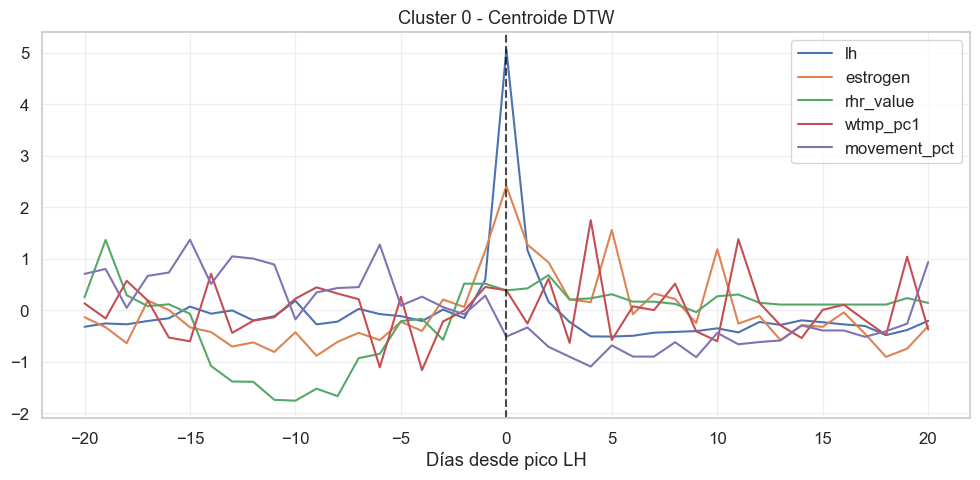

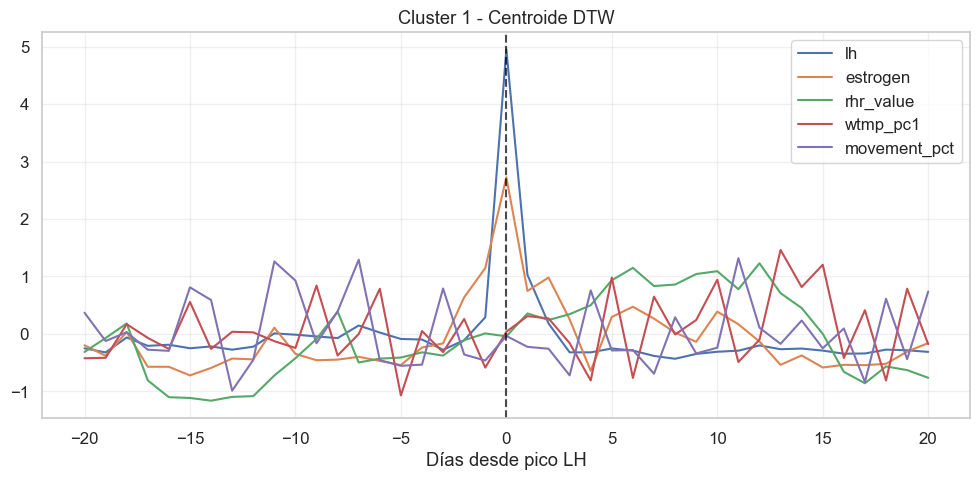

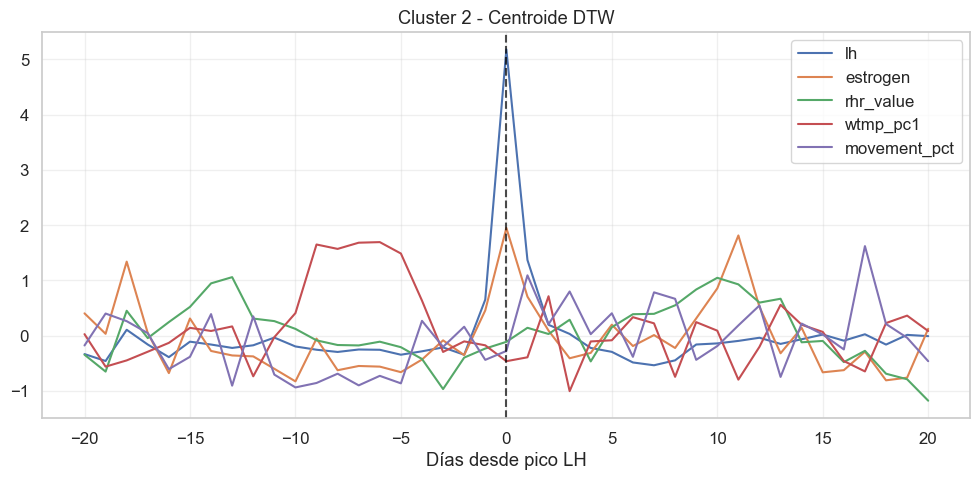

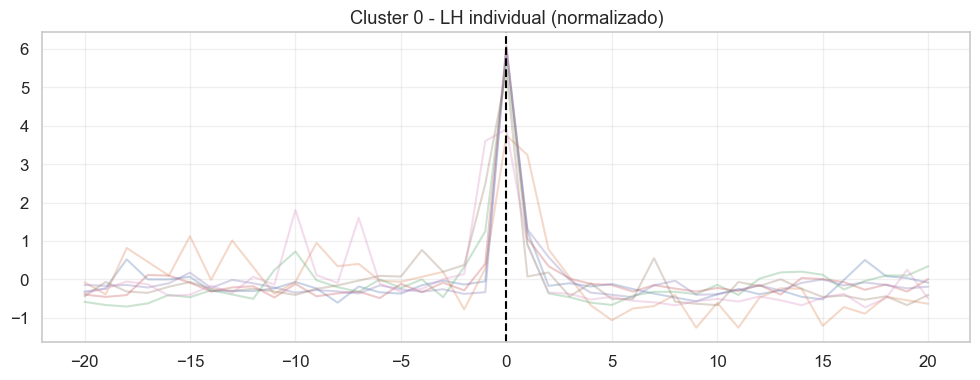

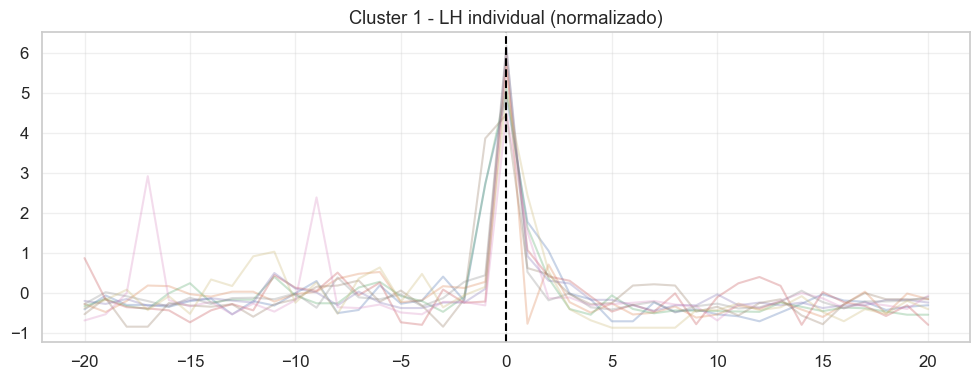

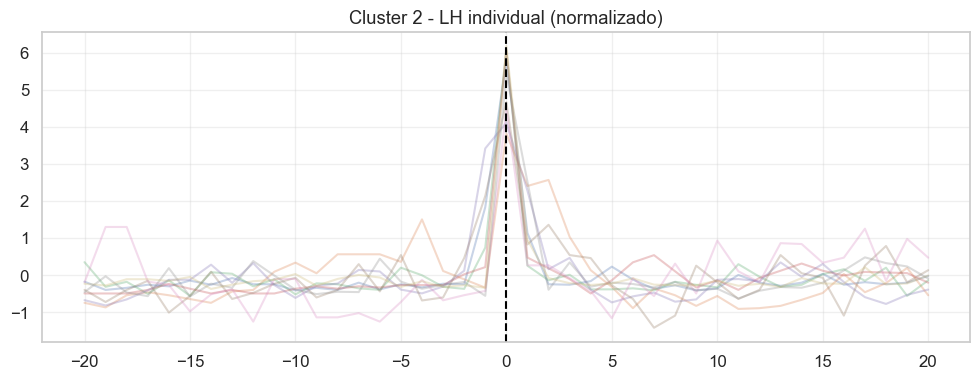

In [68]:
import numpy as np
import pandas as pd

from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans

import matplotlib.pyplot as plt

# ============================================================
# 1. Parámetros
# ============================================================
signals = [
    "lh",
    "estrogen",
    "rhr_value",
    "wtmp_pc1",
    "movement_pct"
]

WINDOW = 20
time_index = np.arange(-WINDOW, WINDOW + 1)

# ============================================================
# 2. Construir series por sujeto (tensor 3D)
# ============================================================
subject_profiles = {}
subjects_valid = []

for sid in aligned_df["id"].unique():

    sub = aligned_df[aligned_df["id"] == sid]

    profile = (
        sub
        .groupby("day_from_lh_peak")[signals]
        .mean()
        .reindex(time_index)
    )

    # eliminar sujetos incompletos
    if profile.isnull().any().any():
        continue

    subject_profiles[sid] = profile.values
    subjects_valid.append(sid)

X = np.array(list(subject_profiles.values()))
print("Shape X:", X.shape)  # (n_subjects, time, variables)

# ============================================================
# 3. Normalización (MUY importante en tslearn)
# ============================================================
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. TimeSeriesKMeans con DTW
# ============================================================
k = 3  # ajusta después (2–5 suele ser razonable)

model = TimeSeriesKMeans(
    n_clusters=k,
    metric="dtw",
    max_iter=10,
    random_state=42,
    n_init=2
)

labels = model.fit_predict(X_scaled)

print("Clusters:", np.unique(labels, return_counts=True))

# ============================================================
# 5. Guardar resultados
# ============================================================
cluster_df = pd.DataFrame({
    "id": subjects_valid,
    "cluster": labels
})

cluster_df.to_csv(OUTPUT_PATH / "clusters_ts_kmeans.csv", index=False)

# ============================================================
# 6. Visualización de centroides (interpretación)
# ============================================================
for c in range(k):

    plt.figure(figsize=(10, 5))

    center = model.cluster_centers_[c]

    for var_i, var in enumerate(signals):
        plt.plot(
            time_index,
            center[:, var_i],
            label=var
        )

    plt.axvline(0, color="black", linestyle="--", alpha=0.7)
    plt.title(f"Cluster {c} - Centroide DTW")
    plt.xlabel("Días desde pico LH")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(
        OUTPUT_PATH / f"kmeans_cluster_{c}_centroid.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 7. Visualización de sujetos por cluster (opcional)
# ============================================================
for c in range(k):

    idx = np.where(labels == c)[0]

    plt.figure(figsize=(10, 4))

    for i in idx:
        # ejemplo: LH únicamente para claridad
        plt.plot(
            time_index,
            X_scaled[i][:, 0],
            alpha=0.3
        )

    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"Cluster {c} - LH individual (normalizado)")
    plt.grid(alpha=0.3)
    plt.savefig(
        OUTPUT_PATH / f"kmeans_cluster_{c}_individual_lh.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()

elegir k

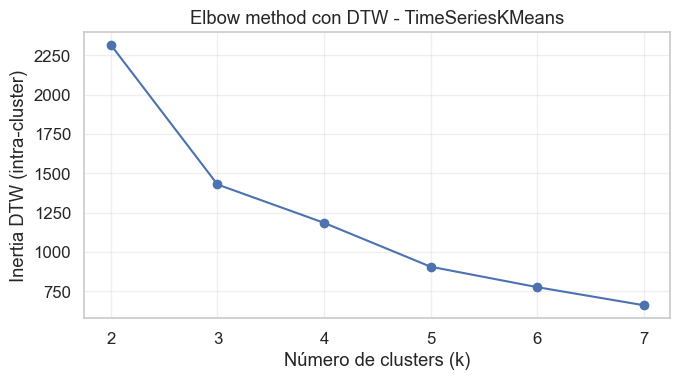

In [67]:
import numpy as np
import matplotlib.pyplot as plt

from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw

# ============================================================
# 1. Ya tienes X (n_subjects, time, features)
# ============================================================

scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 2. Rango de k a evaluar
# ============================================================
k_range = range(2, 8)

inertias = []

# ============================================================
# 3. Loop de clustering
# ============================================================
for k in k_range:

    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=10,
        random_state=42,
        n_init=2
    )

    labels = model.fit_predict(X_scaled)

    # ========================================================
    # 4. Inertia aproximada (DTW intra-cluster)
    # ========================================================
    inertia_k = 0

    for c in np.unique(labels):

        idx = np.where(labels == c)[0]
        cluster = X_scaled[idx]

        if len(cluster) <= 1:
            continue

        D = cdist_dtw(cluster)
        inertia_k += D[np.triu_indices(len(cluster), k=1)].sum()

    inertias.append(inertia_k)

# ============================================================
# 5. Plot Elbow
# ============================================================
plt.figure(figsize=(7,4))

plt.plot(list(k_range), inertias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia DTW (intra-cluster)")
plt.title("Elbow method con DTW - TimeSeriesKMeans")
plt.savefig(
    OUTPUT_PATH / "kmeans_elbow_dtw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ! pip install hdbscan scikit-learn-extra

#### Opción B: K-Medoids con DTW

Shape X: (25, 41, 5)
Calculando matriz DTW...
Clusters: (array([0, 1, 2]), array([7, 9, 9]))
Medoid subjects:
33
41
20


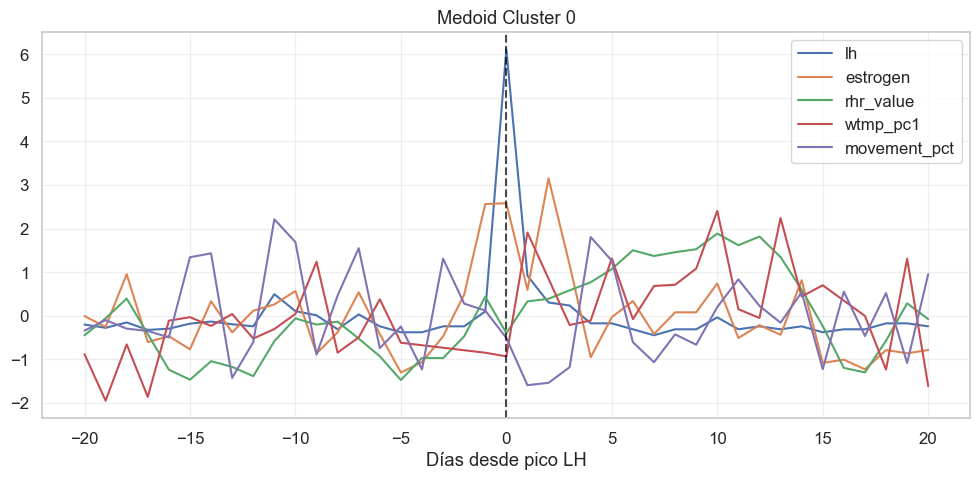

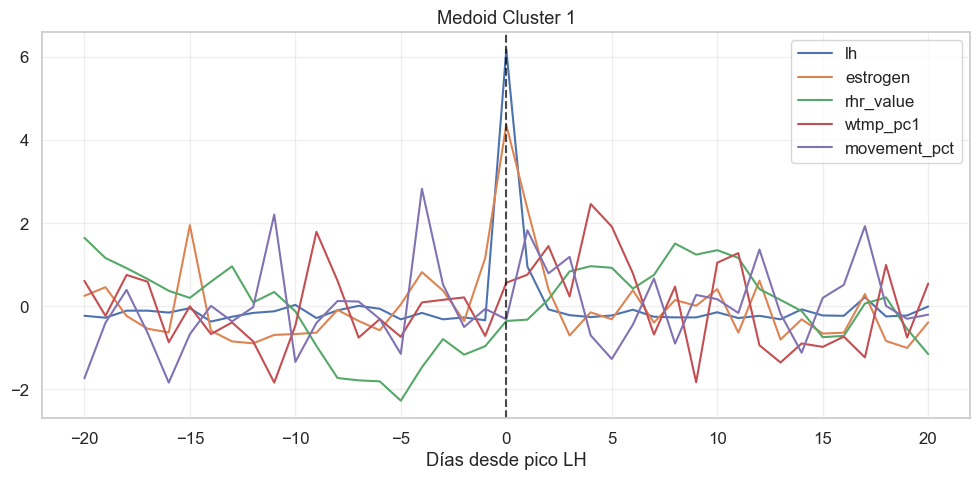

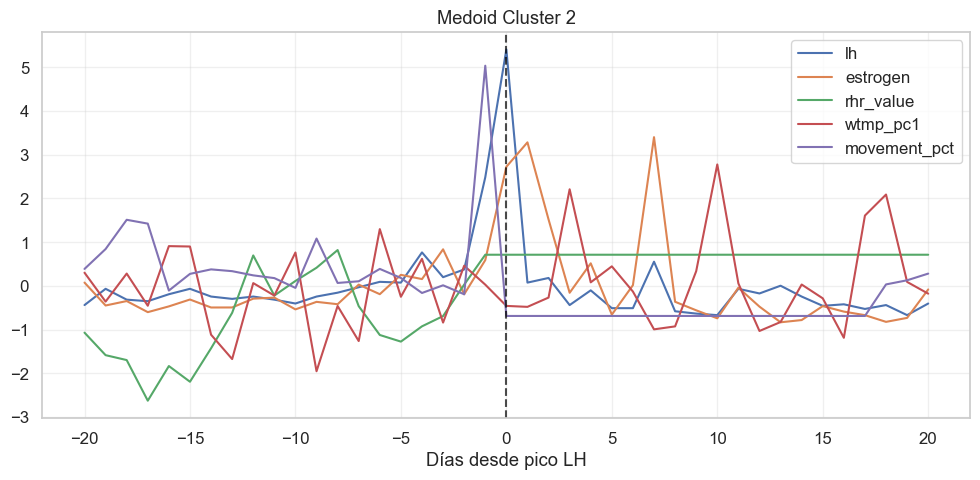

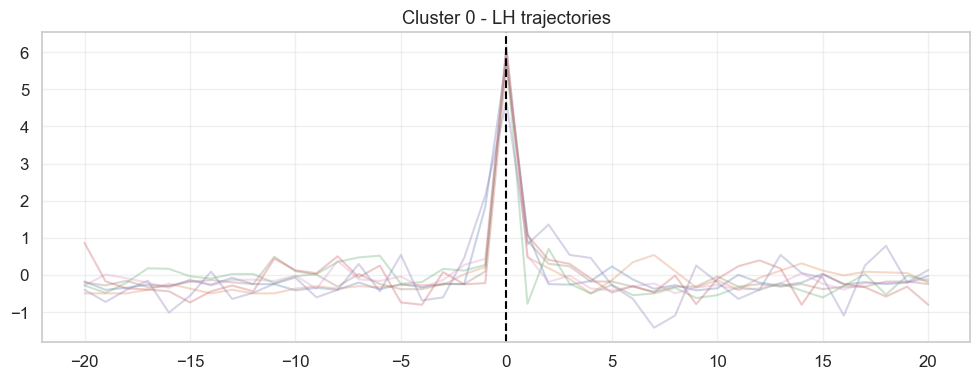

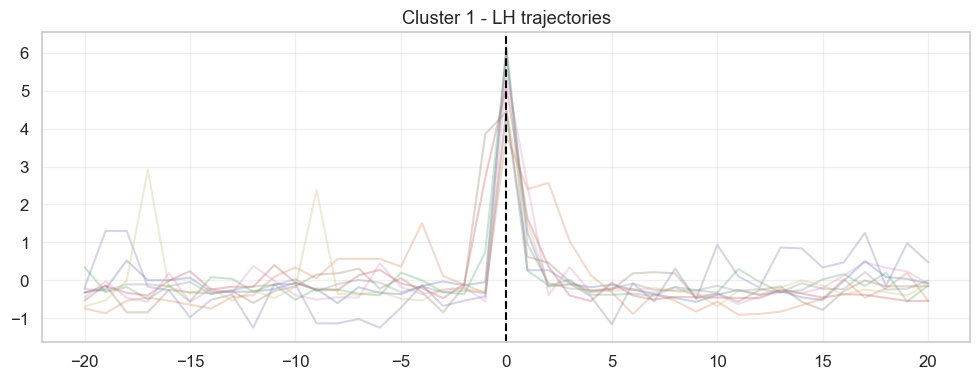

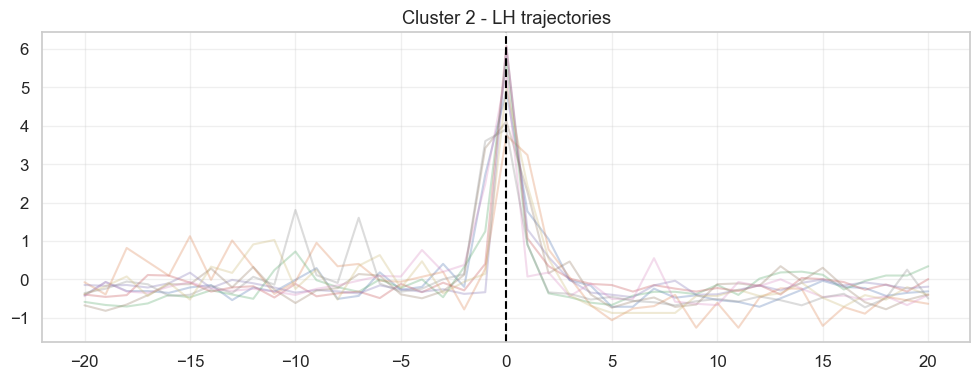

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn_extra.cluster import KMedoids

# ============================================================
# 1. Parámetros
# ============================================================
signals = [
    "lh",
    "estrogen",
    "rhr_value",
    "wtmp_pc1",
    "movement_pct"
]

WINDOW = 20
time_index = np.arange(-WINDOW, WINDOW + 1)

# ============================================================
# 2. Construcción de series por sujeto
# ============================================================
subject_profiles = {}
subjects_valid = []

for sid in aligned_df["id"].unique():

    sub = aligned_df[aligned_df["id"] == sid]

    profile = (
        sub
        .groupby("day_from_lh_peak")[signals]
        .mean()
        .reindex(time_index)
    )

    # filtrar incompletos
    if profile.isnull().any().any():
        continue

    subject_profiles[sid] = profile.values
    subjects_valid.append(sid)

X = np.array(list(subject_profiles.values()))
print("Shape X:", X.shape)

# ============================================================
# 3. Normalización (crítica para DTW multivariado)
# ============================================================
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. Matriz de distancias DTW
# ============================================================
print("Calculando matriz DTW...")
D = cdist_dtw(
    X_scaled.reshape(X_scaled.shape[0], -1)
)

# ============================================================
# 5. K-Medoids
# ============================================================
k = 3  # ajustable con elbow

model = KMedoids(
    n_clusters=k,
    metric="precomputed",
    random_state=42
)

labels = model.fit_predict(D)

print("Clusters:", np.unique(labels, return_counts=True))

# ============================================================
# 6. Guardar clusters
# ============================================================
cluster_df = pd.DataFrame({
    "id": subjects_valid,
    "cluster": labels
})

cluster_df.to_csv(
    OUTPUT_PATH / "clusters_kmedoids_dtw.csv",
    index=False
)

# ============================================================
# 7. Medoids (ejemplos representativos)
# ============================================================
medoid_indices = model.medoid_indices_

print("Medoid subjects:")
for idx in medoid_indices:
    print(subjects_valid[idx])

# ============================================================
# 8. Visualización de medoids
# ============================================================
for m, idx in enumerate(medoid_indices):

    plt.figure(figsize=(10, 5))

    ts = X_scaled[idx]

    for v, sig in enumerate(signals):
        plt.plot(
            time_index,
            ts[:, v],
            label=sig
        )

    plt.axvline(0, color="black", linestyle="--", alpha=0.7)

    plt.title(f"Medoid Cluster {labels[idx]}")
    plt.xlabel("Días desde pico LH")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(
        OUTPUT_PATH / f"kmedoids_cluster_{labels[idx]}_medoid.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 9. Visualización por cluster (LH como ejemplo)
# ============================================================
for c in np.unique(labels):

    idxs = np.where(labels == c)[0]

    plt.figure(figsize=(10, 4))

    for i in idxs:
        plt.plot(
            time_index,
            X_scaled[i][:, 0],  # LH
            alpha=0.3
        )

    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"Cluster {c} - LH trajectories")
    plt.grid(alpha=0.3)
    plt.savefig(
        OUTPUT_PATH / f"kmedoids_cluster_{c}_lh_trajectories.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.tight_layout()
    plt.show()

### Opción C: HDBSCAN (sin k fijo)

Shape X: (25, 41, 5)
Explained variance: 0.6557883969713909
Clusters encontrados: 0
Ruido (outliers): 1.0
Distribución: (array([-1]), array([25]))


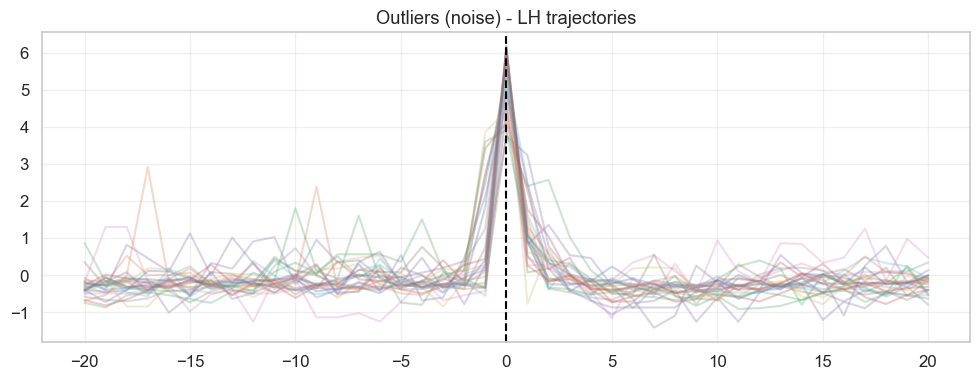

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.decomposition import PCA
import hdbscan

# ============================================================
# 1. Parámetros
# ============================================================
signals = [
    "lh",
    "estrogen",
    "rhr_value",
    "wtmp_pc1",
    "movement_pct"
]

WINDOW = 20
time_index = np.arange(-WINDOW, WINDOW + 1)

# ============================================================
# 2. Construcción de series por sujeto
# ============================================================
subject_profiles = {}
subjects_valid = []

for sid in aligned_df["id"].unique():

    sub = aligned_df[aligned_df["id"] == sid]

    profile = (
        sub
        .groupby("day_from_lh_peak")[signals]
        .mean()
        .reindex(time_index)
    )

    # filtrar incompletos
    if profile.isnull().any().any():
        continue

    subject_profiles[sid] = profile.values
    subjects_valid.append(sid)

X = np.array(list(subject_profiles.values()))
print("Shape X:", X.shape)

# ============================================================
# 3. Normalización (clave para comparabilidad)
# ============================================================
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. Vectorización (para HDBSCAN no usa DTW directo)
# ============================================================
X_flat = X_scaled.reshape(X_scaled.shape[0], -1)

# ============================================================
# 5. Reducción de dimensionalidad (recomendado)
# ============================================================
pca = PCA(n_components=10, random_state=42)
X_red = pca.fit_transform(X_flat)

print("Explained variance:", pca.explained_variance_ratio_.sum())

# ============================================================
# 6. HDBSCAN clustering
# ============================================================
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    metric="euclidean"
)

labels = clusterer.fit_predict(X_red)

# ============================================================
# 7. Resultados básicos
# ============================================================
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_ratio = np.mean(labels == -1)

print("Clusters encontrados:", n_clusters)
print("Ruido (outliers):", noise_ratio)

print("Distribución:", np.unique(labels, return_counts=True))

# ============================================================
# 8. Guardar resultados
# ============================================================
cluster_df = pd.DataFrame({
    "id": subjects_valid,
    "cluster": labels
})

cluster_df.to_csv(
    OUTPUT_PATH / "clusters_hdbscan.csv",
    index=False
)

# ============================================================
# 9. Visualización de clusters (LH como ejemplo)
# ============================================================
unique_clusters = [c for c in np.unique(labels) if c != -1]

for c in unique_clusters:

    idxs = np.where(labels == c)[0]

    plt.figure(figsize=(10, 4))

    for i in idxs:
        plt.plot(
            time_index,
            X_scaled[i][:, 0],  # LH
            alpha=0.3
        )

    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"HDBSCAN Cluster {c} - LH trajectories")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# 10. Visualización de ruido (outliers)
# ============================================================
noise_idx = np.where(labels == -1)[0]

plt.figure(figsize=(10, 4))

for i in noise_idx:
    plt.plot(time_index, X_scaled[i][:, 0], alpha=0.3)

plt.axvline(0, color="black", linestyle="--")
plt.title("Outliers (noise) - LH trajectories")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()